# ASC speed changes with resolution

In [1]:
import cosima_cookbook as cc
from cosima_cookbook import distributed as ccd
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import xarray as xr
import glob,os
import cmocean.cm as cmocean

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

In [2]:
client = Client(n_workers=28)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:34441/status,
Dashboard: http://127.0.0.1:34441/status,Workers: 28
Total threads: 28,Total memory: 251.18 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34143,Workers: 28
Dashboard: http://127.0.0.1:34441/status,Total threads: 28
Started: Just now,Total memory: 251.18 GiB
Comm: tcp://127.0.0.1:43811,Total threads: 1
Dashboard: http://127.0.0.1:44143/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:37659,


In [3]:
exp01 = 'panant-01-zstar-ACCESSyr2'
exp005 = 'panant-005-zstar-ACCESSyr2'
start_time= '2000-01-01'
end_time= '2000-12-31'
lat_range = slice(-90,-59)
isobath_depth = 1000
rho_0 = 1035.0

session = cc.database.create_session()

basedir='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'


Importing ASC speed

In [4]:
import glob

#panan01
gl =glob.glob(basedir + 'panan01/ASC_speed/daily_z/*')
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p01_ASC=xr.open_mfdataset(gl, concat_dim='time', combine='nested')

#panan005
gl =glob.glob(basedir + 'panan005/ASC_speed/daily_z/*')
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p005_ASC=xr.open_mfdataset(gl, concat_dim='time', combine='nested')

12 netcdf data files
0.3.0
12 netcdf data files


In [5]:
# mean speeds
mp01_ASC=p01_ASC.groupby('time.month').mean('time').mean('month')
mp005_ASC=p005_ASC.groupby('time.month').mean('time').mean('month')

Calculating distance along contour for future interpolation

In [6]:
import geopy.distance

def geodistance(X0,X1,Y0,Y1):
    coords_1=[Y0,X0]
    coords_2=[Y1,X1]
    dist=geopy.distance.geodesic(coords_1, coords_2).m
    return dist

In [7]:
#panan01
mp01_dist=np.array(mp01_ASC.contour_index)*0
Lon01=np.array(mp01_ASC.lon_along_contour)
Lat01=np.array(mp01_ASC.lat_along_contour)

for n in (mp01_ASC.contour_index-2):
    mp01_dist[n]=geodistance(Lon01[n],Lon01[n+1],Lat01[n],Lat01[n+1])
mp01_dist=np.cumsum(np.append(0,mp01_dist[:-1]))

#panan005
mp005_dist=np.array(mp005_ASC.contour_index)*0
Lon005=np.array(mp005_ASC.lon_along_contour)
Lat005=np.array(mp005_ASC.lat_along_contour)

for n in (mp005_ASC.contour_index-2):
    mp005_dist[n]=geodistance(Lon005[n],Lon005[n+1],Lat005[n],Lat005[n+1])
mp005_dist=np.cumsum(np.append(0,mp005_dist[:-1]))



We can now use the distances to interpolat mp01 into mp005

In [8]:
mp01_ASC_into005=mp01_ASC.u_along_contour
mp01_ASC_into005['contour_index']=mp01_dist
mp01_ASC_into005=mp01_ASC_into005.interp(contour_index=mp005_dist)
mp01_ASC_into005['contour_index']=np.array(mp005_ASC.contour_index)

In [40]:
#importing the mean shelf mask used in access OM2. How does it look like when compared here to panana?
mean_mask_OM2 = xr.open_dataset('/g/data/v45/txs156/ASC_classification/clustering_mask_time_mean.nc')
mean_u_om2= xr.open_mfdataset('/g/data/v45/wf4500/ASC_project_files/ASC_speed/OM2_IAF/Antarctic_slope_contour_1km_velocities_2*').mean('time')


In [42]:
mean_u_om2

<xarray.Dataset>
Dimensions:                 (st_ocean: 75, contour_index: 6002)
Coordinates:
  * st_ocean                (st_ocean) float64 0.5413 1.681 ... 5.709e+03
  * contour_index           (contour_index) int64 1 2 3 4 ... 6000 6001 6002
Data variables:
    u_along_contour         (st_ocean, contour_index) float32 dask.array<chunksize=(75, 6002), meta=np.ndarray>
    u_cross_contour         (st_ocean, contour_index) float32 dask.array<chunksize=(75, 6002), meta=np.ndarray>
    lon_along_contour       (contour_index) float64 dask.array<chunksize=(6002,), meta=np.ndarray>
    lat_along_contour       (contour_index) float64 dask.array<chunksize=(6002,), meta=np.ndarray>
    thickness_contour       (st_ocean, contour_index) float64 dask.array<chunksize=(75, 6002), meta=np.ndarray>
    distance_along_contour  (contour_index) float64 dask.array<chunksize=(6002,), meta=np.ndarray>

(-280.0, 80.0)

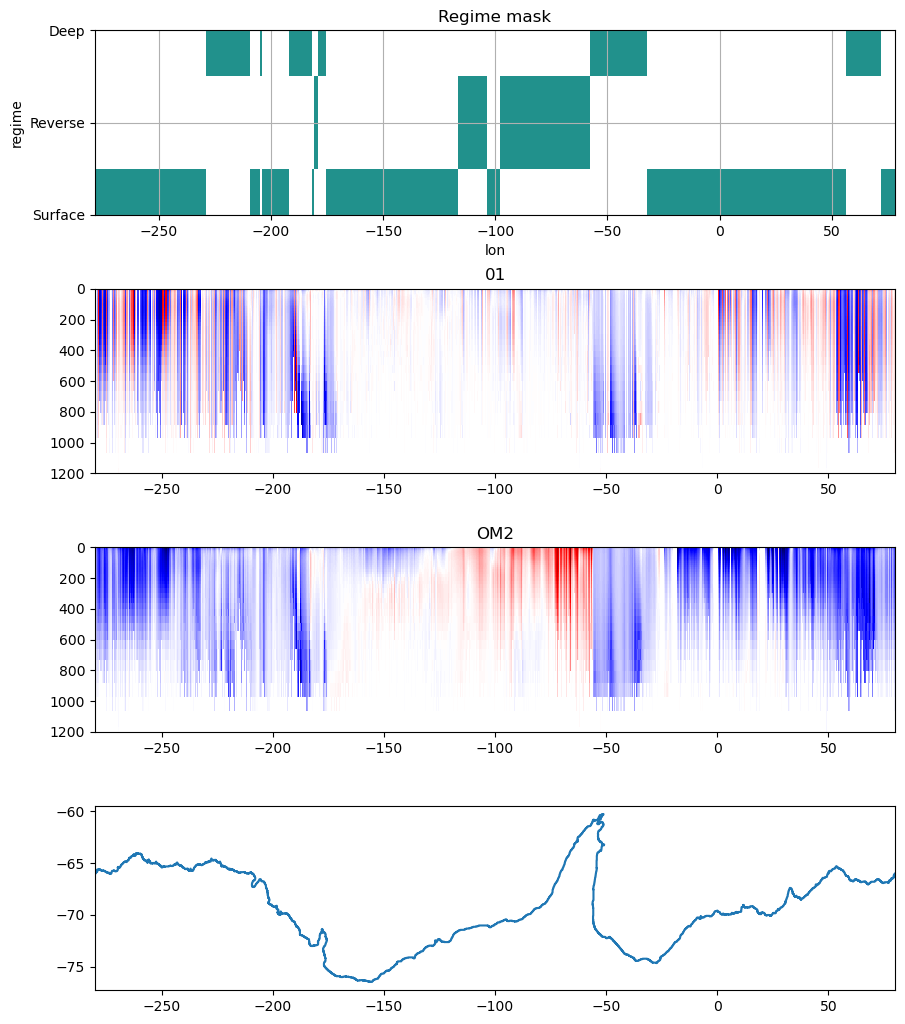

In [44]:
plt.figure(figsize=(10,12))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)

plt.subplot(4,1,2)
plt.pcolormesh(mp01_ASC.lon_along_contour,mp01_ASC.z_l,mp01_ASC.u_along_contour,vmin=-.3,vmax=.3,cmap='seismic')
plt.ylim(1200,0)
plt.title('01')

plt.subplot(4,1,3)
plt.pcolormesh(mean_u_om2.lon_along_contour,mean_u_om2.st_ocean,mean_u_om2.u_along_contour,vmin=-.3,vmax=.3,cmap='seismic')
plt.ylim(1200,0)
plt.title('OM2')

plt.subplot(4,1,1)
mean_mask_OM2.regimes_mask.plot(add_colorbar=False)
# plt.pcolormesh(mp005_ASC.lon_along_contour,mp005_ASC.z_l,\
# mp005_ASC.u_along_contour  - mp01_ASC_into005,vmin=-.3,vmax=.3,cmap='seismic')
# plt.ylim(1200,0)
plt.grid()
plt.title('Regime mask')

plt.subplot(4,1,4)
plt.plot(mp01_ASC.lon_along_contour,mp01_ASC.lat_along_contour )
plt.xlim(-280,80)

The ASC velocities look quite weird on panan. I.e., they are not smoothly negative as in OM2. PErhaps we need to recalculate them, with a little more attention to the grid.